# Player Stats Analysis
Recibe un DataFrame con tracking data de jugadores y genera estadísticas y visualizaciones completas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
import json
import numpy as np

## 1. Cargar datos

In [2]:
# Posiciones normalizadas de cada keypoint en la cancha real
# (x, y) en metros, origen en kp0 (esquina superior izquierda)
# Cancha dobles: 23.77m largo x 10.97m ancho
_COURT_WIDTH  = 10.97
_COURT_LENGTH = 23.77
_SERVICE_BOX  = 6.40   # distancia de la red a la línea de servicio
_DOUBLES_ALLY = 1.37   # ancho del pasillo de dobles

_PLAYER_COLORS = [
    (255, 100, 0), (0, 200, 255), (0, 255, 100),
    (200, 0, 255), (255, 200, 0), (0, 100, 255),
]

In [3]:
df = pd.read_csv('../data/tennis_match_1/player_stats.csv')

print(f"Filas: {len(df)} | Jugadores: {df['player_id'].nunique()} | Frames: {df['frame'].nunique()}")
df.head()

Filas: 445 | Jugadores: 2 | Frames: 224


,frame,player_id,conf,x1,y1,x2,y2,cx,cy,width,height,mx,my,dist_meters,speed_kmh
0,1,1,0.9322,347.51,798.63,497.33,1052.82,422.42,925.72,149.83,254.20,1.1967,22.9777,NaN,NaN
1,1,2,0.7879,1044.55,158.01,1099.86,288.80,1072.20,223.41,55.31,130.80,6.5820,-4.3578,NaN,NaN
2,2,1,0.9276,347.72,800.58,496.36,1054.03,422.04,927.30,148.64,253.45,1.1967,22.9777,0.0000,0.00
3,2,2,0.7407,1047.03,162.72,1102.28,288.71,1074.66,225.71,55.25,125.99,6.6817,-4.1597,0.2218,23.95
4,3,1,0.8734,347.79,801.25,495.81,1054.36,421.80,927.80,148.02,253.11,1.1967,22.9777,0.0000,0.00


In [4]:
with open("../data/tennis_match_1/result.json") as f:
    state = json.load(f)
    
FPS = state["video_data"]["fps"]

In [5]:
df = df.dropna(subset=['dist_meters', 'speed_kmh'])

In [6]:
class PlayerStatsAnalysis:
    def __init__(self, df: pd.DataFrame, fps: dict):
        # player_stats dataframe
        self.df = df.dropna(subset=['dist_meters', 'speed_kmh'])
        self.fps = fps
        # Posiciones normalizadas de cada keypoint en la cancha real
        # (x, y) en metros, origen en kp0 (esquina superior izquierda)
        # Cancha dobles: 23.77m largo x 10.97m ancho
        self._COURT_WIDTH  = 10.97
        self._COURT_LENGTH = 23.77
        self._SERVICE_BOX  = 6.40   # distancia de la red a la línea de servicio
        self._DOUBLES_ALLY = 1.37   # ancho del pasillo de dobles
        self._PLAYER_COLORS = [
            (255, 100, 0), (0, 200, 255), (0, 255, 100),
            (200, 0, 255), (255, 200, 0), (0, 100, 255),
        ]
        self.SPRINT_THRESHOLD_KMH = 20.0   # umbral para contar un sprint
        self.SPEED_BINS = [0, 5, 10, 15, 20, 35]
        self.SPEED_LABELS = ['0-5', '5-10', '10-15', '15-20', '>20']

    def get_color(self, i):
        normalized_colors = [tuple(c / 255 for c in rgb) for rgb in self._PLAYER_COLORS]
        return normalized_colors[i % len(normalized_colors)]
    
    
    def summarize(self, expresed_in_time: bool = False) -> pd.DataFrame:
        """
        Genera un resumen estadístico por jugador. 
        expresed_in_time: 
            Si True, las métricas basadas en frames se expresan en segundos usando fps.
            Si False, se dejan en frames.
        Si se proporciona fps, incluye métricas de tiempo.
        """
        df = self.df
        rows = []
        for pid, grp in df.groupby('player_id'):
            # Limpieza de datos: solo frames donde tenemos telemetría válida
            valid = grp.dropna(subset=['speed_kmh', 'dist_meters'])

            # Lógica de Sprints: Detectar inicios de rachas de alta velocidad
            above = (valid['speed_kmh'] > self.SPRINT_THRESHOLD_KMH).astype(int)
            sprints = (above.diff() == 1).sum()
            if len(above) > 0 and above.iloc[0] == 1:
                sprints += 1  # Contar si empieza el video ya en sprint

            # Métricas base
            frames_moving = int((valid['speed_kmh'] > 1.0).sum())
            frames_total = int(len(grp))

            row = {
                'player_id':      int(pid),
                'dist_total_m':   round(valid['dist_meters'].sum(), 2),
                'speed_max_kmh':  round(valid['speed_kmh'].max(), 2),
                'speed_avg_kmh':  round(valid['speed_kmh'].mean(), 2),
                'sprints':        int(sprints),
                'frames_moving':  frames_moving,
                'frames_total':   frames_total,
            }

            # --- Inyección de lógica temporal si hay FPS ---
            if expresed_in_time and self.fps > 0:
                sprint_runs = []
                in_sprint, count = False, 0
                for v in valid['speed_kmh']:
                    if v > self.SPRINT_THRESHOLD_KMH:
                        in_sprint, count = True, count + 1
                    elif in_sprint:
                        sprint_runs.append(count / self.fps)
                        in_sprint, count = False, 0
                if in_sprint:
                    sprint_runs.append(count / self.fps)

                row['sprint_avg_duration_s'] = round(np.mean(sprint_runs), 2) if sprint_runs else 0
                row['sprint_max_duration_s'] = round(max(sprint_runs), 2)     if sprint_runs else 0

            rows.append(row)

        summary = pd.DataFrame(rows)

        # Cálculos globales del DataFrame resultante
        if not summary.empty:
            summary['pct_moving'] = (summary['frames_moving'] / summary['frames_total'] * 100).round(1)
        return summary
    
    
    def plot_player_speeds(
        self,
        expresed_in_time: bool = False,
        figsize_per_player: tuple = (12, 3.5)
    ) -> None:
        """
        Grafica la velocidad por jugador (frames o tiempo) y marca el umbral de sprint.
        """
        df = self.df
        players = sorted(df['player_id'].dropna().unique().astype(int).tolist())
        num_players = len(players)

        # Configuración de la figura dinámica
        fig, axes = plt.subplots(num_players, 1, 
                                 figsize=(figsize_per_player[0], figsize_per_player[1] * num_players), 
                                 sharex=True)
        if num_players == 1:
            axes = [axes]

        results = []

        for ax, pid in zip(axes, players):
            # 1. Preparación de datos
            grp = df[df['player_id'] == pid].sort_values('frame').copy()

            # Eje X: Frames o Segundos
            x = grp['frame']
            x_label = 'Frame'
            if expresed_in_time and self.fps > 0:
                grp['seconds'] = grp['frame'] / self.fps
                x = grp['seconds']
                x_label = 'Tiempo (s)'

            color = self.get_color(players.index(pid))

            # 3. Plotting
            # Relleno de área (alpha) y línea de velocidad
            ax.fill_between(x, grp['speed_kmh'].fillna(0), alpha=0.15, color=color)
            ax.plot(x, grp['speed_kmh'], color=color, linewidth=1.5, label=f'Jugador {pid}')

            # Línea de umbral de sprint
            ax.axhline(self.SPRINT_THRESHOLD_KMH, color='#E24B4A', linewidth=0.9, linestyle='--', alpha=0.6)

            # 4. Anotaciones y Estilo
            ax.set_ylabel('Velocidad (km/h)', fontsize=10)
            ax.set_title(f'Jugador {pid} — Perfil de Velocidad', fontsize=11, fontweight='600')
            ax.set_ylim(bottom=0)
            ax.grid(axis='y', alpha=0.2, linestyle=':')

            # Texto del umbral al final del gráfico
            ax.text(x.iloc[-1], self.SPRINT_THRESHOLD_KMH + 0.5, f'Sprint {self.SPRINT_THRESHOLD_KMH}km/h', 
                    color='#E24B4A', fontsize=8, ha='right', fontweight='500')

            results.append(grp)

        # Configuración global
        axes[-1].set_xlabel(x_label, fontsize=10)
        fig.suptitle('Análisis de Velocidad Instantánea', fontsize=14, fontweight='700', y=1.01)

        plt.tight_layout()
        plt.show()


    def plot_speed_distribution(self) -> None:
        """
        Grafica la distribución de velocidades por jugador en rangos definidos.
        """
        df = self.df
        players = sorted(df['player_id'].dropna().unique().astype(int).tolist())
        fig, axes = plt.subplots(1, len(players), figsize=(5 * len(players), 4), sharey=False)
        if len(players) == 1:
            axes = [axes]

        for ax, pid in zip(axes, players):
            grp = df[(df['player_id'] == pid)].dropna(subset=['speed_kmh'])
            counts, _ = np.histogram(grp['speed_kmh'], bins=self.SPEED_BINS)
            pcts = counts / counts.sum() * 100
            color = self.get_color(players.index(pid))
            bars = ax.bar(self.SPEED_LABELS, pcts, color=color, alpha=0.85, width=0.6, zorder=3)
            for bar, pct in zip(bars, pcts):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{pct:.1f}%', ha='center', fontsize=9, color='#444')
            ax.set_xlabel('Rango (km/h)', fontsize=10)
            ax.set_ylabel('% de frames', fontsize=10)
            ax.set_title(f'Jugador {pid}', fontsize=11)
            ax.set_ylim(0, max(pcts) * 1.2 + 2)

        fig.suptitle('Distribución de velocidad', fontsize=13, fontweight='500')
        plt.tight_layout()
        plt.show()


    def plot_cumulative_distance(
        self,
        expresed_in_time: bool = False,
        figsize: tuple = (12, 4),
    ) -> pd.DataFrame:
        """
        Grafica la distancia acumulada por jugador a lo largo del partido
        y retorna un DataFrame con los datos calculados.

        Parámetros
        ----------
        df      : DataFrame con columnas dist_meters, player_id, frame
        figsize : tamaño de la figura
        fps     : si se provee, el eje X muestra segundos en lugar de frames

        Retorna
        -------
        DataFrame con columnas: frame, player_id, cumul_dist, [seconds]
        """
        df = self.df
        players = sorted(df['player_id'].dropna().unique().astype(int).tolist())

        results = []
        fig, ax = plt.subplots(figsize=figsize)

        for pid in players:
            grp = (df[df['player_id'] == pid]
                   .sort_values('frame')
                   .copy())

            grp['cumul_dist'] = grp['dist_meters'].fillna(0).cumsum()

            x = grp['frame']
            x_label = 'Frame'
            if expresed_in_time and self.fps > 0:
                grp['seconds'] = grp['frame'] / self.fps
                x = grp['seconds']
                x_label = 'Tiempo (s)'

            #color = PLAYER_COLORS[(pid - 1) % len(PLAYER_COLORS)]
            color = self.get_color(players.index(pid))
            total = grp['cumul_dist'].iloc[-1]

            ax.plot(x, grp['cumul_dist'],
                    color=color, linewidth=2,
                    label=f'Jugador {pid}  ({total:.1f} m)')

            # Anotación del total al final de la línea
            ax.annotate(
                f"{total:.1f} m",
                xy=(x.iloc[-1], total),
                xytext=(6, 0), textcoords='offset points',
                fontsize=8.5, color=color, va='center', fontweight='600'
            )

            results.append(grp[['frame', 'player_id', 'cumul_dist']
                                + (['seconds'] if expresed_in_time and self.fps > 0 else [])])

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel('Distancia acumulada (m)', fontsize=10)
        ax.set_title('Distancia acumulada a lo largo del partido',
                     fontsize=12, fontweight='600')
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.25, linestyle='--')
        plt.tight_layout()
        plt.show()

        return pd.concat(results, ignore_index=True)
    

    def plot_metric_comparison_A(self, summary: pd.DataFrame) -> None:
        """
        Opción A — Subplots independientes por métrica.
        Cada panel tiene su propia escala, preservando valores absolutos.
        Métricas: distancia total, vel. máxima, vel. promedio, sprints, % en movimiento.
        Si están disponibles, agrega duración promedio y máxima de sprint.
        """
        players = sorted(summary['player_id'].dropna().unique().astype(int).tolist())

        base_metrics = [
            ('dist_total_m',  'Distancia total', 'm'),
            ('speed_max_kmh', 'Vel. máxima',     'km/h'),
            ('speed_avg_kmh', 'Vel. promedio',   'km/h'),
            ('sprints',       'Sprints',         ''),
            ('pct_moving',    'Tiempo en movimiento', '%'),
        ]
        extra_metrics = [
            ('sprint_avg_duration_s', 'Duración prom. sprint', 's'),
            ('sprint_max_duration_s', 'Duración máx. sprint',  's'),
        ]
        metrics = base_metrics + [m for m in extra_metrics if m[0] in summary.columns]

        n = len(metrics)
        ncols = 4
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.8))
        axes = axes.flatten()

        width  = 0.55 / len(players)
        colors = [self.get_color(i) for i in range(len(players))]

        for ax_i, (col, label, unit) in enumerate(metrics):
            ax = axes[ax_i]
            x  = np.arange(len(players))

            for i, pid in enumerate(players):
                row  = summary[summary['player_id'] == pid].iloc[0]
                val  = row[col]
                bar  = ax.bar(
                    i, val,
                    color=colors[i], alpha=0.85, zorder=3,
                    label=f'J{pid}' if ax_i == 0 else None,
                )
                # Valor encima de la barra
                ax.text(
                    i, val + ax.get_ylim()[1] * 0.01 if ax.get_ylim()[1] > 0 else val + 0.1,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8.5,
                    color='#333',
                )

            ylabel = f'{label} ({unit})' if unit else label
            ax.set_ylabel(ylabel, fontsize=8.5)
            ax.set_title(label, fontsize=9.5, fontweight='500', pad=6)
            ax.set_xticks(range(len(players)))
            ax.set_xticklabels([f'J{p}' for p in players], fontsize=9)
            ax.grid(axis='y', alpha=0.18, linestyle='--')
            ax.set_axisbelow(True)
            # Reajustar ylim para dejar espacio a las etiquetas
            ymax = summary[col].max()
            ax.set_ylim(0, ymax * 1.18 if ymax > 0 else 1)

        # Ocultar subplots sobrantes
        for j in range(len(metrics), len(axes)):
            axes[j].set_visible(False)

        handles = [
            plt.Rectangle((0, 0), 1, 1, color=colors[i], alpha=0.85)
            for i in range(len(players))
        ]
        fig.legend(
            handles, [f'Jugador {p}' for p in players],
            loc='lower right', fontsize=9,
            bbox_to_anchor=(0.98, 0.01),
            framealpha=0.7,
        )
        fig.suptitle('Comparación de métricas por jugador', fontsize=13, fontweight='600', y=1.01)
        plt.tight_layout()
        plt.show()


    def plot_metric_comparison_B(self, summary: pd.DataFrame) -> None:
        """
        Opción B — Radar/spider chart normalizado (0-100).
        Cada métrica se escala relativa al máximo entre jugadores.
        Ideal para mostrar el perfil de rendimiento relativo de cada jugador.
        Métricas incluidas: distancia total, vel. máxima, vel. promedio, sprints, % en movimiento.
        Si están disponibles: duración prom. sprint, duración máx. sprint.
        """

        players = sorted(summary['player_id'].dropna().unique().astype(int).tolist())

        base_metrics = [
            ('dist_total_m',  'Distancia\ntotal'),
            ('speed_max_kmh', 'Vel.\nmáxima'),
            ('speed_avg_kmh', 'Vel.\npromedio'),
            ('sprints',       'Sprints'),
            ('pct_moving',    '% tiempo\nmovimiento'),
        ]
        extra_metrics = [
            ('sprint_avg_duration_s', 'Sprint\nprom. (s)'),
            ('sprint_max_duration_s', 'Sprint\nmáx. (s)'),
        ]
        metrics = base_metrics + [m for m in extra_metrics if m[0] in summary.columns]

        cols   = [m[0] for m in metrics]
        labels = [m[1] for m in metrics]
        N      = len(metrics)

        # Normalizar 0-100 respecto al máximo entre jugadores
        maxvals = summary[cols].max()
        norm    = summary[cols].div(maxvals.replace(0, 1)).mul(100)

        # Ángulos del radar
        angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
        angles += angles[:1]   # cerrar polígono

        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)

        # Grilla
        ax.set_rlim(0, 110)
        ax.set_rticks([25, 50, 75, 100])
        ax.set_yticklabels(['25', '50', '75', '100'], fontsize=7.5, color='gray')
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=9.5)
        ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
        ax.spines['polar'].set_visible(False)

        for i, pid in enumerate(players):
            row    = norm[summary['player_id'] == pid].iloc[0]
            values = row[cols].tolist()
            values += values[:1]

            color = self.get_color(i)
            ax.plot(angles, values, color=color, linewidth=2, zorder=3, label=f'Jugador {pid}')
            ax.fill(angles, values, color=color, alpha=0.12)

            # Puntos en cada vértice con valor real anotado
            real_row = summary[summary['player_id'] == pid].iloc[0]
            for angle, val_norm, col in zip(angles[:-1], values[:-1], cols):
                real_val = real_row[col]
                unit_map = {
                    'dist_total_m': 'm', 'speed_max_kmh': 'km/h', 'speed_avg_kmh': 'km/h',
                    'sprints': '', 'pct_moving': '%',
                    'sprint_avg_duration_s': 's', 'sprint_max_duration_s': 's',
                }
                unit = unit_map.get(col, '')
                fmt  = f'{real_val:.0f}{unit}' if unit else f'{real_val:.0f}'

                # Offset radial para separar etiquetas de jugadores distintos
                r_offset = val_norm + 4 + i * 6
                ax.annotate(
                    fmt,
                    xy=(angle, val_norm),
                    xytext=(angle, r_offset),
                    fontsize=7.5,
                    color=color,
                    ha='center', va='center',
                )
                ax.plot(angle, val_norm, 'o', color=color, markersize=5, zorder=4)

        ax.legend(
            loc='upper right',
            bbox_to_anchor=(1.28, 1.12),
            fontsize=10,
            framealpha=0.7,
        )
        ax.set_title(
            'Perfil de rendimiento relativo por jugador\n(normalizado al máximo del grupo)',
            fontsize=11, fontweight='600', pad=20,
        )
        plt.tight_layout()
        plt.show()

    def draw_court_matplotlib(self, ax, margin: float = 1.5) -> None:
        """
        Dibuja la cancha cenital en un eje matplotlib.
        margin: metros extra alrededor de la cancha (para ver jugadores fuera).
        """
        net_y   = self._COURT_LENGTH / 2
        sv_top  = net_y - self._SERVICE_BOX
        sv_bot  = net_y + self._SERVICE_BOX
        inner_l = self._DOUBLES_ALLY
        inner_r = self._COURT_WIDTH - self._DOUBLES_ALLY
        mid_x   = self._COURT_WIDTH / 2

        # Fondos
        ax.set_facecolor('#0f3d0f')                                    # fuera: verde oscuro
        ax.add_patch(plt.Rectangle(                                      # cancha: verde medio
            (0, 0), self._COURT_WIDTH, self._COURT_LENGTH,
            facecolor='#3a6b35', zorder=0
        ))
        for y0, y1 in [(sv_top, net_y), (net_y, sv_bot)]:               # cuadros de servicio
            ax.add_patch(plt.Rectangle(
                (inner_l, y0), inner_r - inner_l, y1 - y0,
                facecolor='#4a7c3f', zorder=1
            ))

        kw  = dict(color='white', linewidth=1.2, alpha=0.9, solid_capstyle='round', zorder=3)
        kw2 = dict(color='white', linewidth=2.0, alpha=0.95, zorder=3)
        kw_net = dict(color='#a0c8ff', linewidth=2.5, zorder=4)

        # Borde exterior
        ax.plot([0, self._COURT_WIDTH, self._COURT_WIDTH, 0, 0],
                [0, 0, self._COURT_LENGTH, self._COURT_LENGTH, 0], **kw2)
        # Pasillos de dobles
        ax.plot([inner_l, inner_l], [0, self._COURT_LENGTH], **kw)
        ax.plot([inner_r, inner_r], [0, self._COURT_LENGTH], **kw)
        # Líneas de servicio
        ax.plot([inner_l, inner_r], [sv_top, sv_top], **kw)
        ax.plot([inner_l, inner_r], [sv_bot, sv_bot], **kw)
        # T central
        ax.plot([mid_x, mid_x], [sv_top, sv_bot], **kw)
        # Red
        ax.plot([0, self._COURT_WIDTH], [net_y, net_y], **kw_net)
        ax.plot(mid_x, net_y, 'o', color='#a0c8ff', markersize=3, zorder=5)
        # Marcas de centro en líneas de fondo
        ax.plot([mid_x - 0.15, mid_x + 0.15], [0, 0],            **kw2)
        ax.plot([mid_x - 0.15, mid_x + 0.15], [self._COURT_LENGTH]*2,  **kw2)

        ax.set_xlim(-margin, self._COURT_WIDTH  + margin)
        ax.set_ylim(-margin, self._COURT_LENGTH + margin)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=7)


    def plot_trajectories_combined(
        self, 
        margin: float = 2.0,
        figsize: tuple = (6.5, 10.5),
        flip_view: bool = False
    ) -> None:
        """
        Visualiza la trayectoria de todos los jugadores en una sola cancha cenital.
        Misma lógica que plot_trajectories: colormap plasma por velocidad,
        scatter inicio/fin, colorbar, stats en leyenda.

        Parámetros
        ----------
        df     : DataFrame con columnas mx, my, speed_kmh, dist_meters, player_id, frame
        margin : metros extra fuera de la cancha visibles
        figsize: tamaño de la figura
        """
        df = self.df
        players = sorted(df['player_id'].dropna().unique().astype(int).tolist())

        fig, ax = plt.subplots(figsize=figsize)
        self.draw_court_matplotlib(ax, margin=margin)

        cmap = plt.cm.plasma

        # Normalización global de velocidad (todos los jugadores comparten escala)
        v_global_max = df['speed_kmh'].max(skipna=True)
        norm = mcolors.Normalize(vmin=0, vmax=max(v_global_max, 1))

        for pid in players:
            grp = (
                df[df['player_id'] == pid]
                .dropna(subset=['mx', 'my'])
                .sort_values('frame')
            )
            if grp.empty:
                continue

            xs     = grp['mx'].values
            ys     = grp['my'].values
            speeds = grp['speed_kmh'].fillna(0).values

            # Trayectoria coloreada por velocidad (plasma, igual que original)
            for i in range(1, len(xs)):
                c = cmap(norm(speeds[i]))
                ax.plot(
                    [xs[i - 1], xs[i]], [ys[i - 1], ys[i]],
                    color=c, linewidth=1.8, alpha=0.82, zorder=6,
                )

            # Inicio / fin
            ax.scatter(xs[0],  ys[0],  color='#00ff88', s=75, zorder=8,
                       marker='o', edgecolors='white', linewidths=0.8)
            ax.scatter(xs[-1], ys[-1], color='#ff4444', s=75, zorder=8,
                       marker='o', edgecolors='white', linewidths=0.8)

            # Etiqueta de jugador junto al punto de inicio
            ax.text(xs[0] + 0.25, ys[0] + 0.25, f'J{pid}',
                    fontsize=9, fontweight='bold', color='white', zorder=10,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='#111', alpha=0.7, edgecolor='none'))

            # Entrada en leyenda con stats
            d_total = grp['dist_meters'].sum() if 'dist_meters' in grp.columns else 0
            v_max   = speeds.max()
            ax.plot([], [], color='white', linewidth=2.5,
                    label=f'J{pid}  |  {d_total:.0f} m  |  v_max {v_max:.1f} km/h')

        # Entradas de leyenda para inicio / fin
        ax.scatter([], [], color='#00ff88', s=55, marker='o',
                   edgecolors='white', linewidths=0.5, label='Inicio')
        ax.scatter([], [], color='#ff4444', s=55, marker='o',
                   edgecolors='white', linewidths=0.5, label='Fin')

        ax.legend(
            fontsize=8, loc='lower left',
            facecolor='#1a1a1a', labelcolor='white',
            edgecolor='#555', framealpha=0.85,
        )

        # Colorbar de velocidad compartida
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='km/h', fraction=0.025, pad=0.02)

        ax.set_xlabel('Ancho (m)', fontsize=9)
        ax.set_ylabel('Largo (m)', fontsize=9)
        ax.set_title('Trayectoria real coloreada por velocidad',
                     fontsize=11, fontweight='600', pad=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')

        if flip_view:
            # Esto invierte el eje Y: lo que era 20m ahora está abajo y 0m arriba (para q se vea como en el video)
            ax.invert_yaxis()

        plt.tight_layout()
        plt.show()

    def plot_heatmaps_combined(
        self, 
        margin: float = 2.0,
        figsize: tuple = (6.5, 10.5),
        bins: int = 50,
        sigma: float = 1.5,
        flip_view: bool = False,
    ) -> None:
        """
        Mapa de calor de posiciones de todos los jugadores en una sola cancha cenital.
        Cada jugador usa su propio colormap; los mapas se superponen semitransparentes.
        Etiqueta de texto en el punto de máxima densidad de cada jugador.

        Parámetros
        ----------
        df        : DataFrame con columnas mx, my, player_id
        margin    : metros extra fuera de la cancha visibles
        bins      : resolución de la grilla del heatmap
        sigma     : suavizado gaussiano (mayor = más difuso)
        flip_view : si True, invierte el eje Y
        """
        df = self.df
        players = sorted(df['player_id'].dropna().unique().astype(int).tolist())

        x_min, x_max = -margin, self._COURT_WIDTH  + margin
        y_min, y_max = -margin, self._COURT_LENGTH + margin

        fig, ax = plt.subplots(figsize=figsize)
        self.draw_court_matplotlib(ax, margin=margin)

        for idx, pid in enumerate(players):
            grp = df[df['player_id'] == pid].dropna(subset=['mx', 'my'])
            if grp.empty:
                continue

            xs = grp['mx'].values
            ys = grp['my'].values

            # Grilla 2D de densidad
            heatmap, xedges, yedges = np.histogram2d(
                xs, ys,
                bins=bins,
                range=[[x_min, x_max], [y_min, y_max]],
            )

            # Suavizado gaussiano
            heatmap = gaussian_filter(heatmap.T, sigma=sigma)

            # Normalizar 0-1 y enmascarar ceros
            heatmap = heatmap / heatmap.max()
            heatmap_masked = np.ma.masked_where(heatmap < 0.01, heatmap)

            # Overlay sobre la cancha
            ax.imshow(
                heatmap_masked,
                origin='lower',
                extent=[x_min, x_max, y_min, y_max],
                cmap='hot',
                alpha=0.55,
                aspect='auto',
                vmin=0, vmax=1,
                zorder=5 + idx,
            )

            # Punto de máxima densidad
            iy, ix = np.unravel_index(np.argmax(heatmap), heatmap.shape)
            peak_x = xedges[ix] + (xedges[1] - xedges[0]) / 2
            peak_y = yedges[iy] + (yedges[1] - yedges[0]) / 2
            ax.scatter(peak_x, peak_y, color='white', s=80, zorder=10 + idx,
                       marker='x', linewidths=2)

            # Etiqueta en el pico de densidad
            ax.text(
                peak_x + 0.25, peak_y + 0.25, f'J{pid}',
                fontsize=9, fontweight='bold', color='white', zorder=12 + idx,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#111', alpha=0.7, edgecolor='none'),
            )

        # Colorbar única compartida
        sm = plt.cm.ScalarMappable(cmap='hot', norm=mcolors.Normalize(vmin=0, vmax=1))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
        cbar.set_label('Densidad relativa', fontsize=8)
        cbar.set_ticks([0, 0.5, 1])
        cbar.set_ticklabels(['Baja', 'Media', 'Alta'])

        ax.set_xlabel('Ancho (m)', fontsize=9)
        ax.set_ylabel('Largo (m)', fontsize=9)
        ax.set_title('Mapa de calor — posiciones en cancha', fontsize=11, fontweight='600', pad=8)

        if flip_view:
            ax.invert_yaxis()

        plt.tight_layout()
        plt.show()

In [7]:
player_stats_analysis = PlayerStatsAnalysis(
    fps = state["video_data"]["fps"], 
    df = df
)

## 2. Resumen estadístico por jugador

In [8]:
player_stats_analysis.summarize(expresed_in_time=False)

,player_id,dist_total_m,speed_max_kmh,speed_avg_kmh,sprints,frames_moving,frames_total,pct_moving
0,1,16.09,33.86,7.83,14,127,222,57.2
1,2,19.83,33.85,10.20,27,145,210,69.0


In [9]:
summarize = player_stats_analysis.summarize(expresed_in_time=True)
summarize

,player_id,dist_total_m,speed_max_kmh,speed_avg_kmh,sprints,frames_moving,frames_total,sprint_avg_duration_s,sprint_max_duration_s,pct_moving
0,1,16.09,33.86,7.83,14,127,222,0.05,0.07,57.2
1,2,19.83,33.85,10.20,27,145,210,0.04,0.07,69.0


## 3. Velocidad en el tiempo

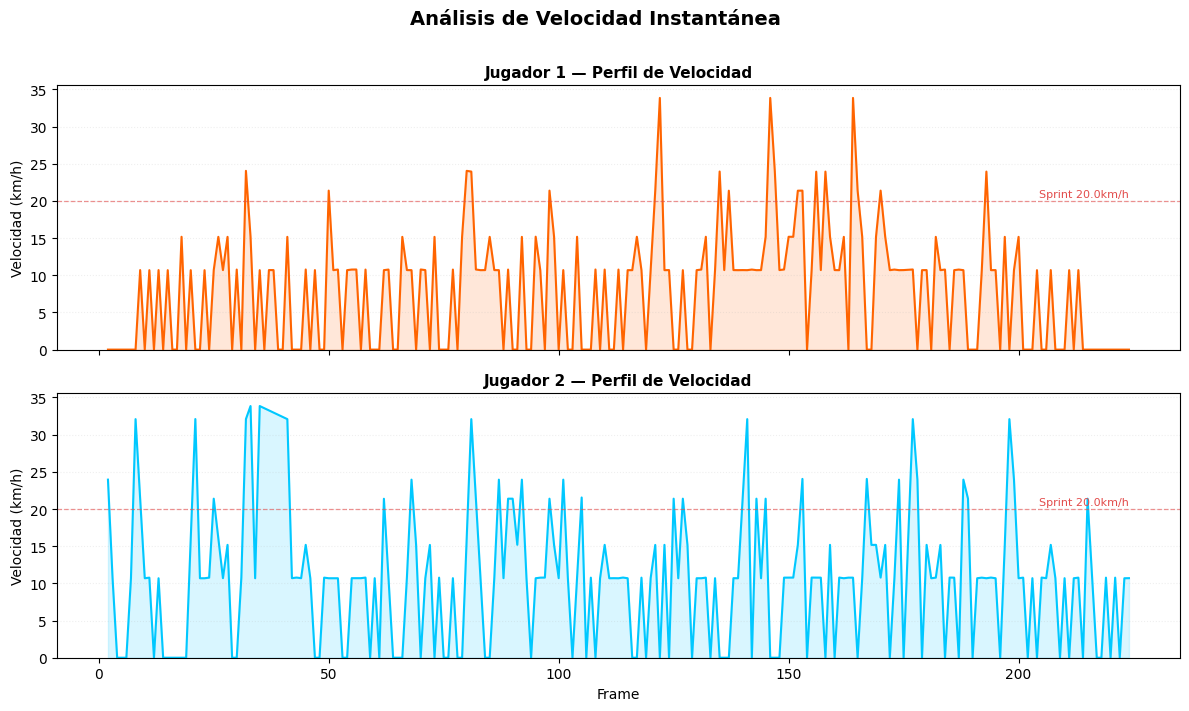

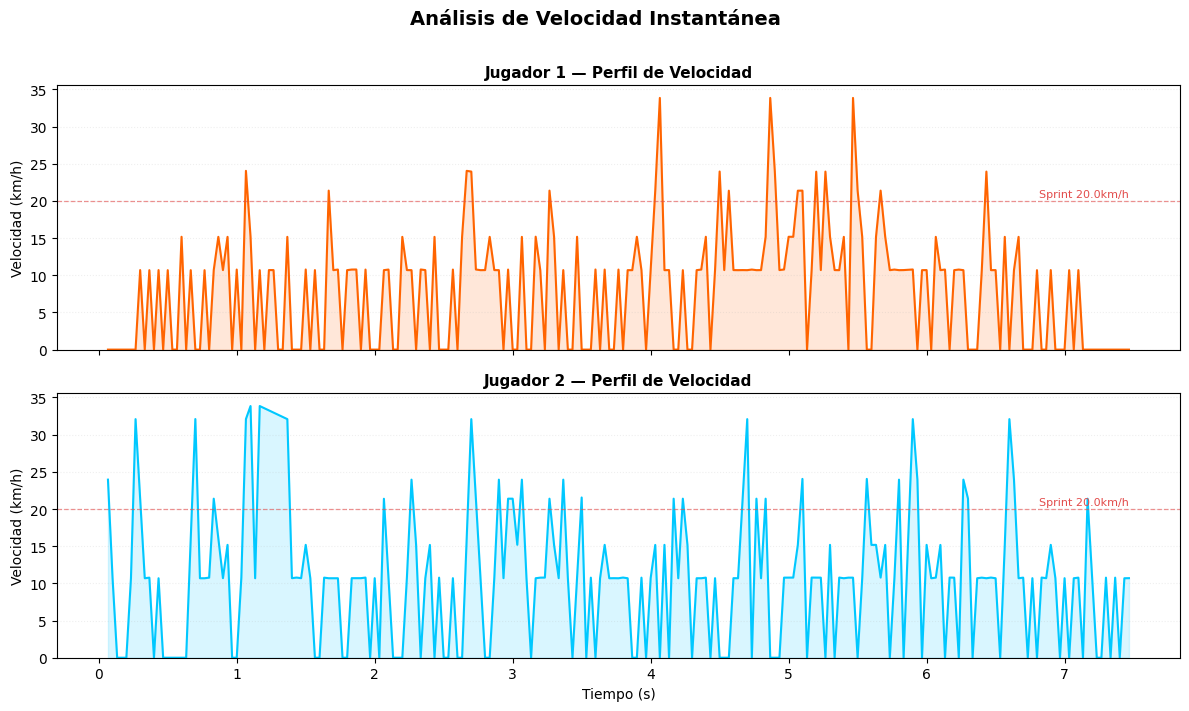

In [10]:
player_stats_analysis.plot_player_speeds()
player_stats_analysis.plot_player_speeds(expresed_in_time=True)

## 4. Distribución de velocidad por rangos

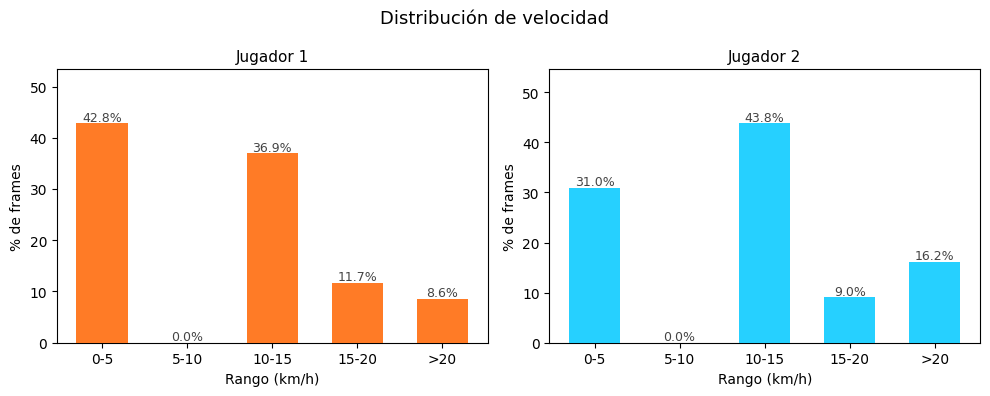

In [11]:
player_stats_analysis.plot_speed_distribution()

## 5. Distancia acumulada

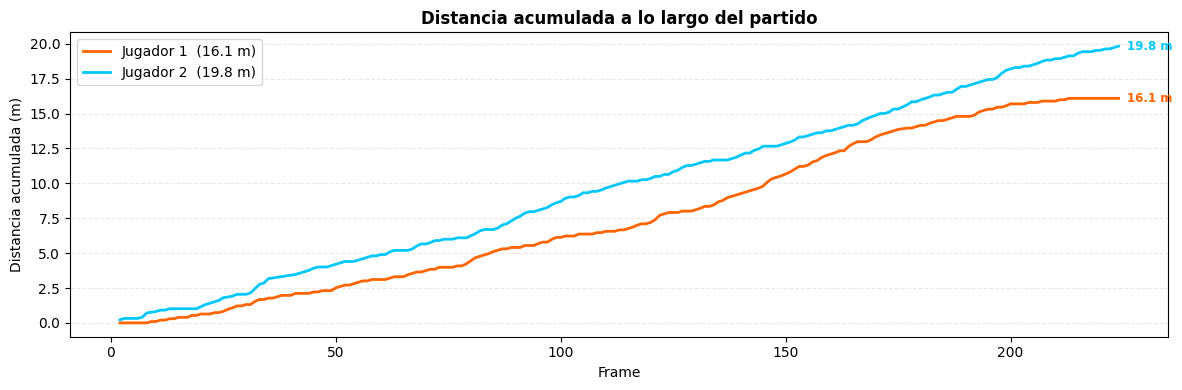

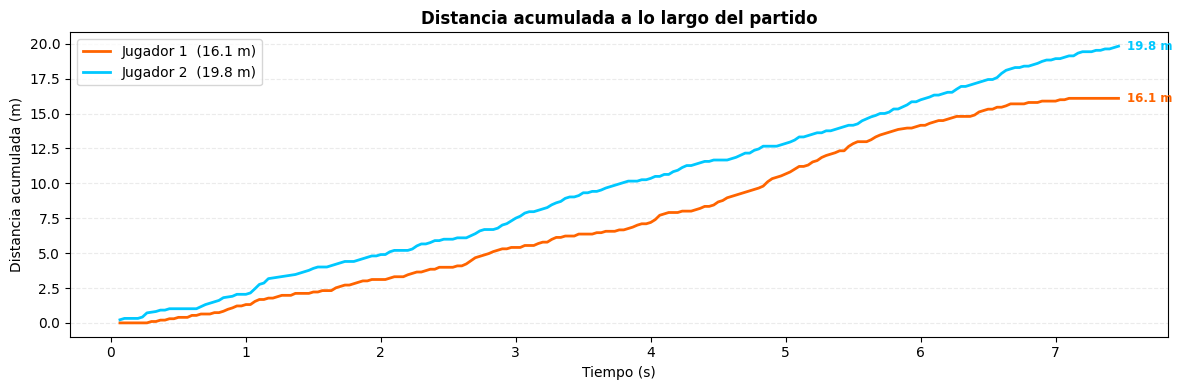

player_id
1    16.0914
2    19.8301
Name: cumul_dist, dtype: float64

In [12]:
# Eje X en frames
result_df = player_stats_analysis.plot_cumulative_distance()
result_df = player_stats_analysis.plot_cumulative_distance(expresed_in_time=True)
# Revisar el DataFrame retornado
result_df.groupby('player_id')['cumul_dist'].max()

## 6. Comparación entre jugadores

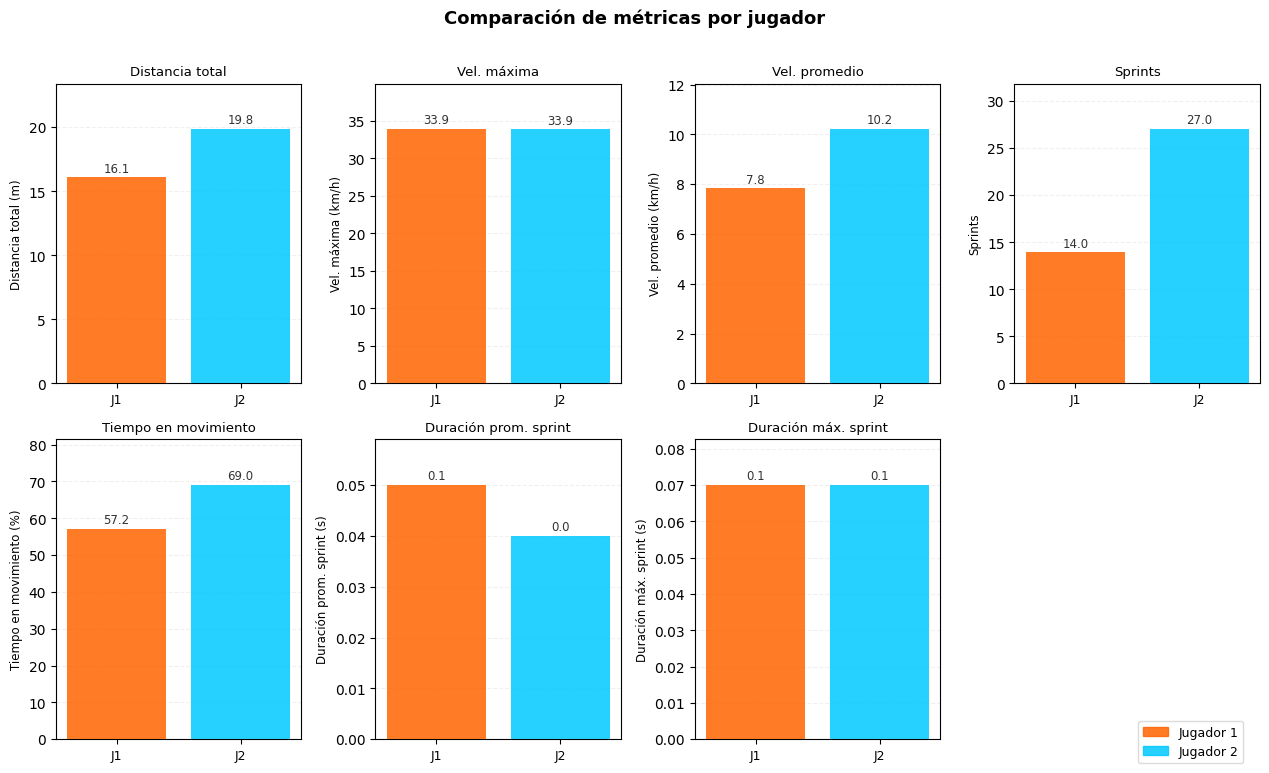

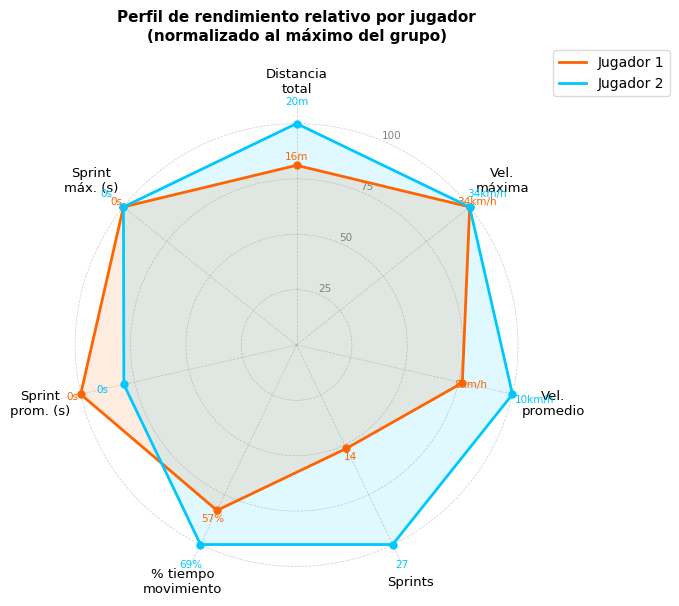

In [13]:
player_stats_analysis.plot_metric_comparison_A(summarize)
player_stats_analysis.plot_metric_comparison_B(summarize)

## 7. Trayectoria real (mx, my)

In [14]:
def draw_court_matplotlib(ax, margin: float = 1.5) -> None:
    """
    Dibuja la cancha cenital en un eje matplotlib.
    margin: metros extra alrededor de la cancha (para ver jugadores fuera).
    """
    net_y   = _COURT_LENGTH / 2
    sv_top  = net_y - _SERVICE_BOX
    sv_bot  = net_y + _SERVICE_BOX
    inner_l = _DOUBLES_ALLY
    inner_r = _COURT_WIDTH - _DOUBLES_ALLY
    mid_x   = _COURT_WIDTH / 2

    # Fondos
    ax.set_facecolor('#0f3d0f')                                      # fuera: verde oscuro
    ax.add_patch(plt.Rectangle(                                      # cancha: verde medio
        (0, 0), _COURT_WIDTH, _COURT_LENGTH,
        facecolor='#3a6b35', zorder=0
    ))
    for y0, y1 in [(sv_top, net_y), (net_y, sv_bot)]:               # cuadros de servicio
        ax.add_patch(plt.Rectangle(
            (inner_l, y0), inner_r - inner_l, y1 - y0,
            facecolor='#4a7c3f', zorder=1
        ))

    kw  = dict(color='white', linewidth=1.2, alpha=0.9, solid_capstyle='round', zorder=3)
    kw2 = dict(color='white', linewidth=2.0, alpha=0.95, zorder=3)
    kw_net = dict(color='#a0c8ff', linewidth=2.5, zorder=4)

    # Borde exterior
    ax.plot([0, _COURT_WIDTH, _COURT_WIDTH, 0, 0],
            [0, 0, _COURT_LENGTH, _COURT_LENGTH, 0], **kw2)
    # Pasillos de dobles
    ax.plot([inner_l, inner_l], [0, _COURT_LENGTH], **kw)
    ax.plot([inner_r, inner_r], [0, _COURT_LENGTH], **kw)
    # Líneas de servicio
    ax.plot([inner_l, inner_r], [sv_top, sv_top], **kw)
    ax.plot([inner_l, inner_r], [sv_bot, sv_bot], **kw)
    # T central
    ax.plot([mid_x, mid_x], [sv_top, sv_bot], **kw)
    # Red
    ax.plot([0, _COURT_WIDTH], [net_y, net_y], **kw_net)
    ax.plot(mid_x, net_y, 'o', color='#a0c8ff', markersize=3, zorder=5)
    # Marcas de centro en líneas de fondo
    ax.plot([mid_x - 0.15, mid_x + 0.15], [0, 0],            **kw2)
    ax.plot([mid_x - 0.15, mid_x + 0.15], [_COURT_LENGTH]*2,  **kw2)

    ax.set_xlim(-margin, _COURT_WIDTH  + margin)
    ax.set_ylim(-margin, _COURT_LENGTH + margin)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)


def plot_trajectories(df: pd.DataFrame,
                      margin: float = 2.0,
                      figsize_per_player: tuple = (5.5, 9)) -> None:
    """
    Visualiza la trayectoria completa de cada jugador coloreada por velocidad.

    Parámetros
    ----------
    df               : DataFrame con columnas mx, my, speed_kmh, player_id, frame
    mc               : instancia de MiniCourt ya calibrada (solo se usa para
                       proyectar puntos extra si los necesitas; aquí usamos
                       mx/my del df directamente)
    margin           : metros extra fuera de la cancha que se muestran
    figsize_per_player: tamaño por subplot
    """
    players = sorted(df['player_id'].dropna().unique().astype(int).tolist())
    n = len(players)
    fw, fh = figsize_per_player
    fig, axes = plt.subplots(1, n, figsize=(fw * n, fh))
    if n == 1:
        axes = [axes]

    for ax, pid in zip(axes, players):
        grp = (df[df['player_id'] == pid]
               .dropna(subset=['mx', 'my'])
               .sort_values('frame'))

        draw_court_matplotlib(ax, margin=margin)

        if grp.empty:
            ax.set_title(f'Jugador {pid} — sin datos', fontsize=11)
            continue

        xs     = grp['mx'].values
        ys     = grp['my'].values
        speeds = grp['speed_kmh'].fillna(0).values

        # Trayectoria coloreada por velocidad
        norm = mcolors.Normalize(vmin=0, vmax=max(speeds.max(), 1))
        cmap = plt.cm.plasma
        for i in range(1, len(xs)):
            c = cmap(norm(speeds[i]))
            ax.plot([xs[i-1], xs[i]], [ys[i-1], ys[i]],
                    color=c, linewidth=1.8, alpha=0.85, zorder=6)

        # Inicio / fin
        ax.scatter(xs[0],  ys[0],  color='#00ff88', s=70,
                   zorder=8, label='Inicio', edgecolors='white', linewidths=0.5)
        ax.scatter(xs[-1], ys[-1], color='#ff4444', s=70,
                   zorder=8, label='Fin',    edgecolors='white', linewidths=0.5)

        # Colorbar velocidad
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='km/h', fraction=0.03, pad=0.02)

        # Stats en el título
        d_total = grp['dist_meters'].sum()
        v_max   = speeds.max()
        ax.set_title(
            f'Jugador {pid}  |  dist: {d_total:.1f} m  |  v_max: {v_max:.1f} km/h',
            fontsize=10, pad=8
        )
        ax.set_xlabel('Ancho (m)', fontsize=9)
        ax.set_ylabel('Largo (m)', fontsize=9)
        ax.legend(fontsize=8, loc='upper right',
                  facecolor='#1a1a1a', labelcolor='white')

        # Línea de referencia: zona fuera de cancha
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')

    fig.suptitle('Trayectoria real coloreada por velocidad',
                 fontsize=13, fontweight='600', color='#222', y=1.01)
    plt.tight_layout()
    plt.show()

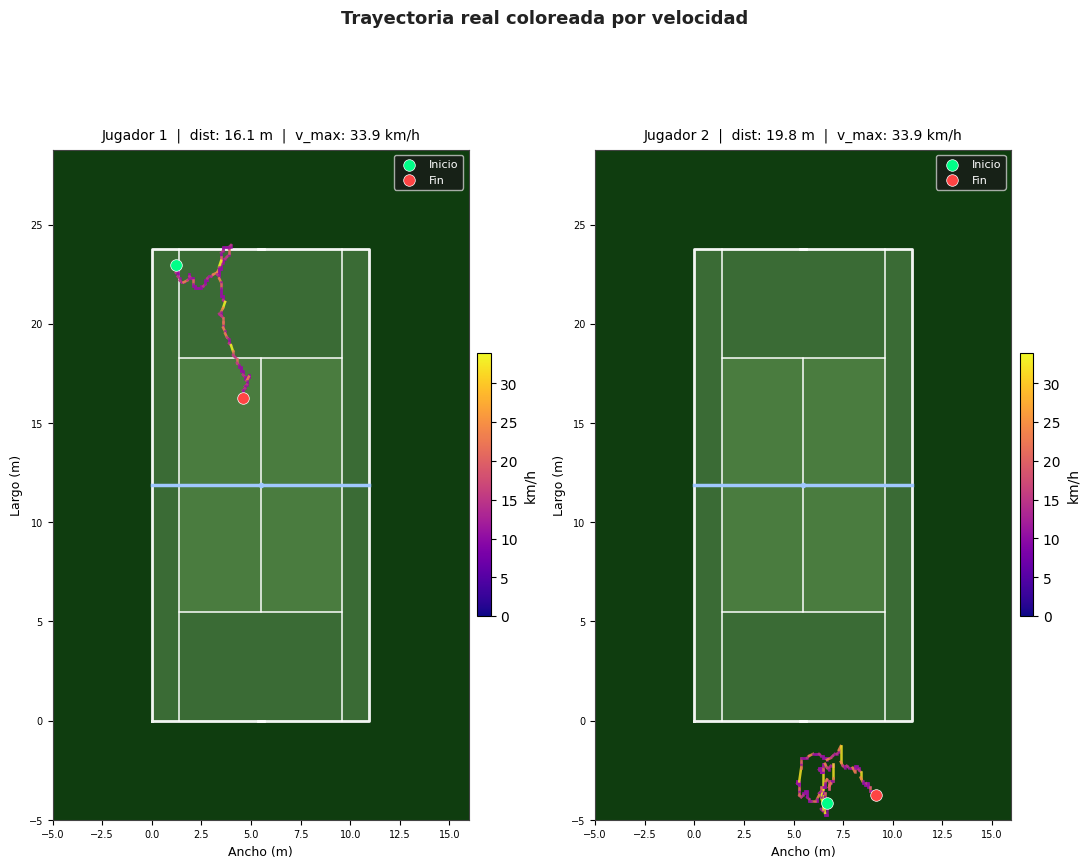

In [15]:
plot_trajectories(df, margin=5.0)

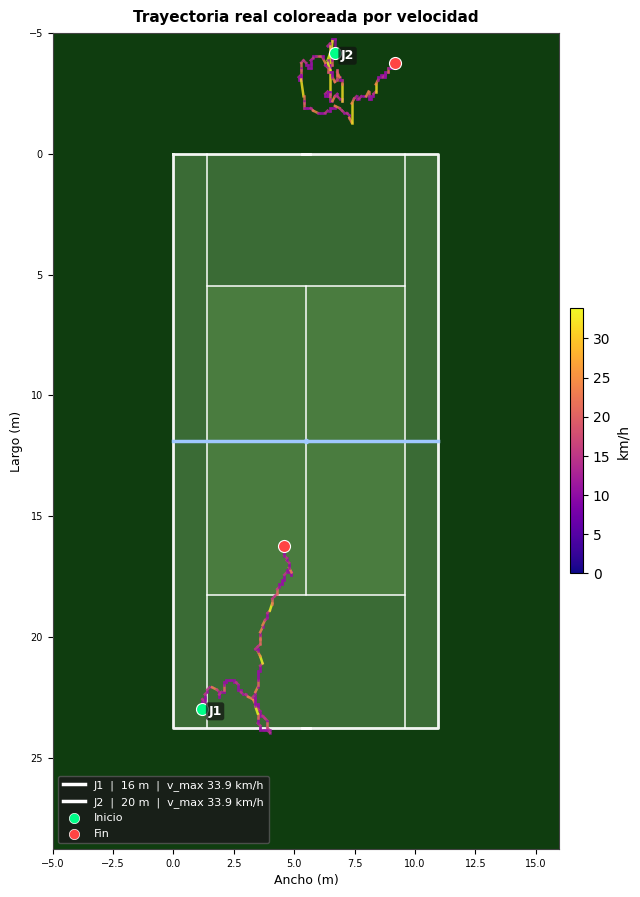

In [16]:
player_stats_analysis.plot_trajectories_combined(margin=5.0, flip_view=True)

## 9. Heatmap de posición en cancha

In [17]:
def plot_heatmaps(df: pd.DataFrame, margin: float = 2.0,
                  figsize_per_player: tuple = (5.5, 9),
                  bins: int = 50, sigma: float = 1.5) -> None:
    """
    Mapa de calor de posiciones de cada jugador sobre la cancha.

    Parámetros
    ----------
    df                 : DataFrame con columnas mx, my, player_id
    margin             : metros extra fuera de la cancha visibles
    bins               : resolución de la grilla del heatmap
    sigma              : suavizado gaussiano (mayor = más difuso)
    """
    players = sorted(df['player_id'].dropna().unique().astype(int).tolist())
    n = len(players)
    fw, fh = figsize_per_player
    fig, axes = plt.subplots(1, n, figsize=(fw * n, fh))
    if n == 1:
        axes = [axes]

    x_min, x_max = -margin, _COURT_WIDTH  + margin
    y_min, y_max = -margin, _COURT_LENGTH + margin

    for ax, pid in zip(axes, players):
        grp = (df[df['player_id'] == pid]
               .dropna(subset=['mx', 'my']))

        draw_court_matplotlib(ax, margin=margin)

        if grp.empty:
            ax.set_title(f'Jugador {pid} — sin datos', fontsize=11)
            continue

        xs = grp['mx'].values
        ys = grp['my'].values

        # Grilla 2D de densidad
        heatmap, xedges, yedges = np.histogram2d(
            xs, ys,
            bins=bins,
            range=[[x_min, x_max], [y_min, y_max]]
        )

        # Suavizado gaussiano
        heatmap = gaussian_filter(heatmap.T, sigma=sigma)

        # Normalizar 0-1 y enmascarar ceros
        heatmap = heatmap / heatmap.max()
        heatmap_masked = np.ma.masked_where(heatmap < 0.01, heatmap)

        # Overlay sobre la cancha
        ax.imshow(
            heatmap_masked,
            origin='lower',
            extent=[x_min, x_max, y_min, y_max],
            cmap='hot',
            alpha=0.65,
            aspect='auto',
            vmin=0, vmax=1,
            zorder=5
        )

        # Punto de máxima densidad
        iy, ix = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        peak_x = xedges[ix] + (xedges[1] - xedges[0]) / 2
        peak_y = yedges[iy] + (yedges[1] - yedges[0]) / 2
        ax.scatter(peak_x, peak_y, color='white', s=80, zorder=9,
                   marker='x', linewidths=2, label=f'Zona más frecuente')

        # Colorbar
        sm = plt.cm.ScalarMappable(
            cmap='hot',
            norm=mcolors.Normalize(vmin=0, vmax=1)
        )
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label('Densidad relativa', fontsize=8)
        cbar.set_ticks([0, 0.5, 1])
        cbar.set_ticklabels(['Baja', 'Media', 'Alta'])

        n_frames = len(grp)
        ax.set_title(
            f'Jugador {pid}  |  {n_frames} posiciones',
            fontsize=10, pad=8
        )
        ax.set_xlabel('Ancho (m)', fontsize=9)
        ax.set_ylabel('Largo (m)', fontsize=9)
        ax.legend(fontsize=8, loc='upper right',
                  facecolor='#1a1a1a', labelcolor='white')

    fig.suptitle('Mapa de calor — posiciones en cancha',
                 fontsize=13, fontweight='600', y=1.01)

    plt.tight_layout()
    plt.show()

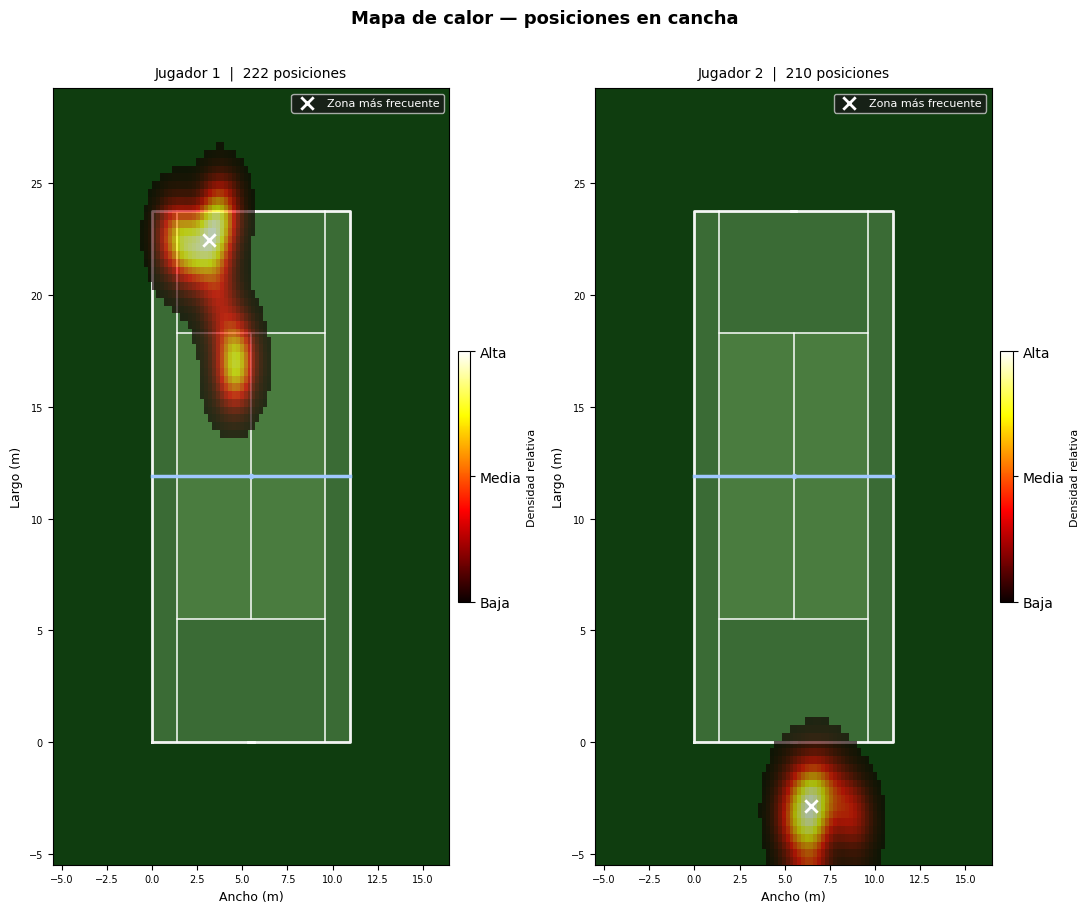

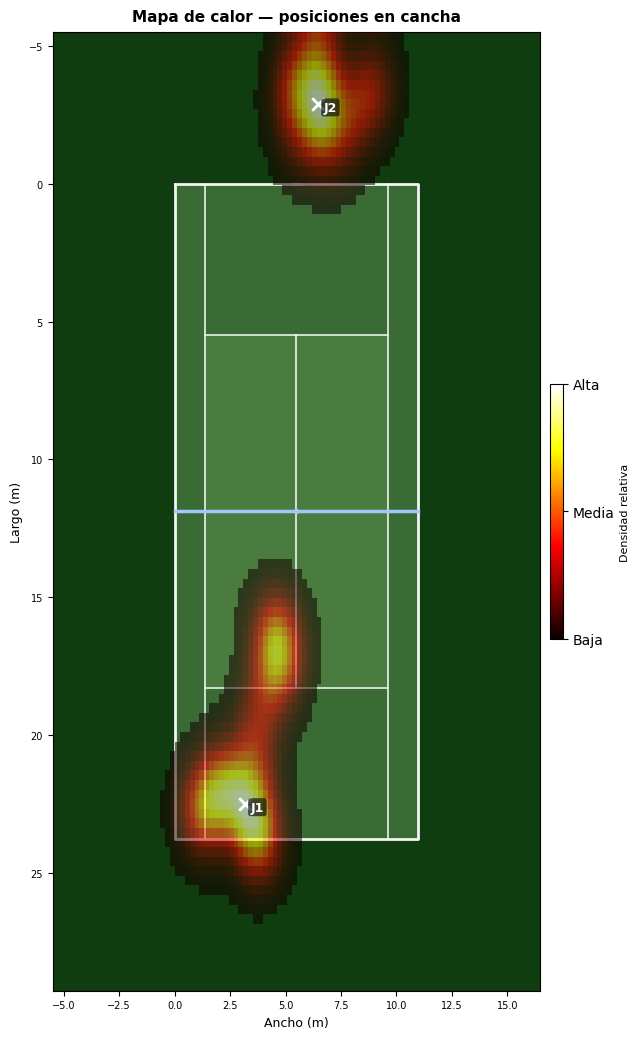

In [18]:
plot_heatmaps(df, margin=5.5, bins=100, sigma=3.0)
player_stats_analysis.plot_heatmaps_combined(margin=5.5, bins=100, sigma=3.0, flip_view=True)

## 10. Zonas de la cancha => tiempo en cada zona

In [19]:
def plot_zone_time(
    df: pd.DataFrame,
    zones: dict = None,
    figsize_per_player: tuple = (4.5, 4.5),
) -> None:
    """
    Gráfico de torta con el % de tiempo que cada jugador pasa en cada zona.
    Las zonas por defecto se derivan directamente de los keypoints reales
    de la cancha (_KP_REAL_COORDS), usando la red y las líneas de servicio
    como fronteras exactas.

    Zonas por defecto (eje Y, metros desde kp0):
      - Fondo        : fondo de cancha → línea de servicio  (kp8/kp10)
      - Servicio     : línea de servicio → red              (net = _COURT_LENGTH/2)
      - Red          : red → línea de servicio rival
      - Fondo rival  : línea de servicio rival → fondo rival

    Parámetros
    ----------
    df      : DataFrame con columnas my, player_id
    zones   : dict nombre -> (y_min, y_max) en metros. Si None usa las zonas
              derivadas de _KP_REAL_COORDS.
    """
    if zones is None:
        # Extraer coordenadas Y exactas desde los keypoints
        net_y     = _COURT_LENGTH / 2                      # red: mitad exacta
        sv_top_y  = _KP_REAL_COORDS[8][1]                  # línea servicio lado 0  (kp8 o kp9)
        sv_bot_y  = _KP_REAL_COORDS[10][1]                 # línea servicio lado 1  (kp10 o kp11)
        top_y     = _KP_REAL_COORDS[0][1]                  # fondo lado 0  = 0.0
        bot_y     = _KP_REAL_COORDS[2][1]                  # fondo lado 1  = _COURT_LENGTH

        zones = {
            'Fondo':          (top_y,    sv_top_y),   # 0.0  → 5.485
            'Servicio':       (sv_top_y, net_y),       # 5.485 → 11.885
            'Servicio rival': (net_y,    sv_bot_y),    # 11.885 → 18.285
            'Fondo rival':    (sv_bot_y, bot_y),       # 18.285 → 23.77
        }

    zone_colors = ['#7F77DD', '#1D9E75', '#1D9E75', '#7F77DD']
    # Servicio y Servicio rival comparten color (misma distancia de la red),
    # Fondo y Fondo rival también. Así la simetría es visualmente clara.

    players = sorted(df['player_id'].dropna().unique().astype(int).tolist())

    # Calcular porcentajes
    zone_data = {}
    for pid in players:
        grp   = df[(df['player_id'] == pid) & df['my'].notna()]
        total = len(grp)
        if total == 0:
            zone_data[pid] = {z: 0.0 for z in zones}
            continue
        zone_data[pid] = {
            name: round(((grp['my'] >= lo) & (grp['my'] < hi)).sum() / total * 100, 1)
            for name, (lo, hi) in zones.items()
        }

    # Plot
    n = len(players)
    fw, fh = figsize_per_player
    fig, axes = plt.subplots(1, n, figsize=(fw * n, fh))
    if n == 1:
        axes = [axes]

    for ax, pid in zip(axes, players):
        z      = zone_data[pid]
        values = list(z.values())
        labels = list(z.keys())

        filtered = [(v, l, c) for v, l, c in zip(values, labels, zone_colors) if v > 0]
        if not filtered:
            ax.set_title(f'Jugador {pid} — sin datos', fontsize=11)
            continue
        values_f, labels_f, colors_f = zip(*filtered)

        wedges, texts, autotexts = ax.pie(
            values_f,
            labels=labels_f,
            autopct='%1.1f%%',
            colors=colors_f,
            startangle=90,
            wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
        )
        for t in texts:
            t.set_fontsize(9)
        for at in autotexts:
            at.set_fontsize(8.5)
            at.set_color('white')
            at.set_fontweight('600')

        grp      = df[(df['player_id'] == pid) & df['my'].notna()]
        n_frames = len(grp)
        ax.set_title(f'Jugador {pid}  |  {n_frames} frames', fontsize=11, pad=12)

    fig.suptitle('Tiempo (%) por zona de la cancha',
                 fontsize=13, fontweight='600', y=1.02)
    plt.tight_layout()
    plt.show()

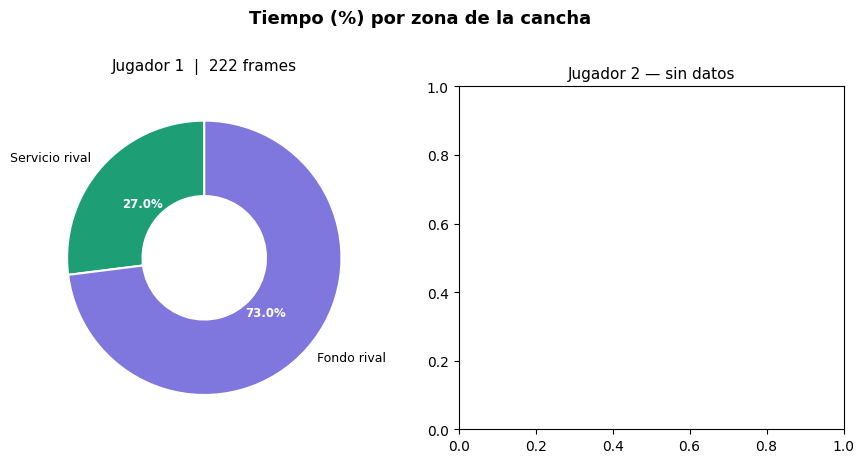

In [21]:
# Zonas por defecto (defensiva / media / ofensiva)
_KP_REAL_COORDS = {
    # Esquinas externas
    0:  (0.0,                        0.0),
    1:  (_COURT_WIDTH,               0.0),
    2:  (0.0,                        _COURT_LENGTH),
    3:  (_COURT_WIDTH,               _COURT_LENGTH),
    # Líneas de dobles internas (separación de pasillo)
    4:  (_DOUBLES_ALLY,              0.0),
    5:  (_DOUBLES_ALLY,              _COURT_LENGTH),
    6:  (_COURT_WIDTH - _DOUBLES_ALLY, 0.0),
    7:  (_COURT_WIDTH - _DOUBLES_ALLY, _COURT_LENGTH),
    # Líneas de servicio
    8:  (_DOUBLES_ALLY,              _COURT_LENGTH / 2 - _SERVICE_BOX),
    9:  (_COURT_WIDTH - _DOUBLES_ALLY, _COURT_LENGTH / 2 - _SERVICE_BOX),
    10: (_DOUBLES_ALLY,              _COURT_LENGTH / 2 + _SERVICE_BOX),
    11: (_COURT_WIDTH - _DOUBLES_ALLY, _COURT_LENGTH / 2 + _SERVICE_BOX),
    # Centro de la red
    12: (_COURT_WIDTH / 2,           _COURT_LENGTH / 2 - _SERVICE_BOX),
    13: (_COURT_WIDTH / 2,           _COURT_LENGTH / 2 + _SERVICE_BOX),
}
plot_zone_time(df)